In [60]:
import numpy as np
import time
import matplotlib as mpl
import matplotlib.pyplot as plt
from DESolver import DESolver

from problems_ODEs import ProblemsODE
from problems_PDEs import ProblemsPDE

import pickle
import os

import seaborn as sns
sns.set_context("talk", font_scale=1.) # "talk"
TEND=0.1
#KAPPA=np.asarray([1e+03,2e+03])
#KAPPA=np.asarray([1e-01,2e-01])
KAPPA=np.asarray([0.,0.])
pde_problem_setup_base={'mx':200,
                        'n':2,
                        'Flux':'linear-advection',
                        'Flux_c':1.,
                        'BC':'periodic',
                        'x_min':0.,
                        'x_max':1.,
                        'kappa':KAPPA, 
                        'IC':'Test1',
                        's':np.asarray([0,1]),
                        'alpha':np.asarray([0,0]),
                        'alpha_i':np.asarray([1,1]),
                        'Flux_name':'1stOrderUpwindFV'}

#'alpha_i':np.asarray([1,1]),

#'1stOrderUpwindFV'
#'3rdOrderUpwindFD'
#'FVStagVanLeer-k=1'
#'FVStagVanLeer-k=1/3'
#                        '

CFL = 10.0
RHS function did not provide a Jacobian, skipping checks for this function
Computing the Jacobian for RHS_I function
=============RHS_I===========================
Norm of the coded Jacobian: 5642.694391866354
Norm of the finite difference Jacobian: 5656.854236519654
Norm of the difference: 5649.778750230429
Maximum difference value position: (254, 54) out of (400, 400) with a value of 200.0000010937697


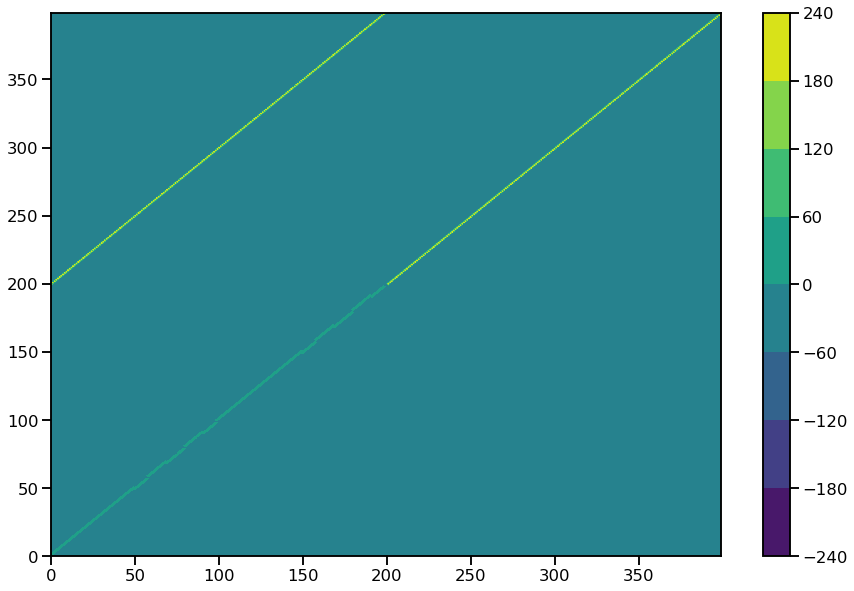

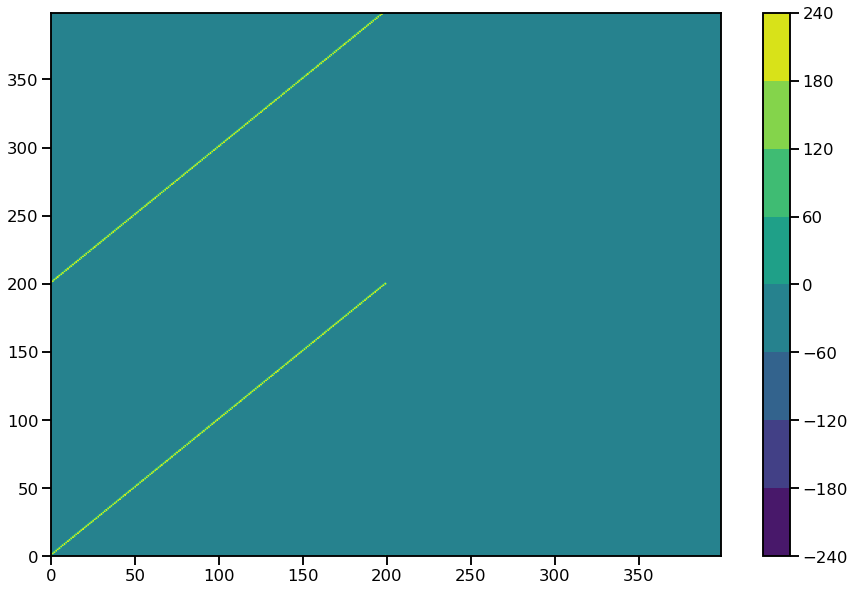

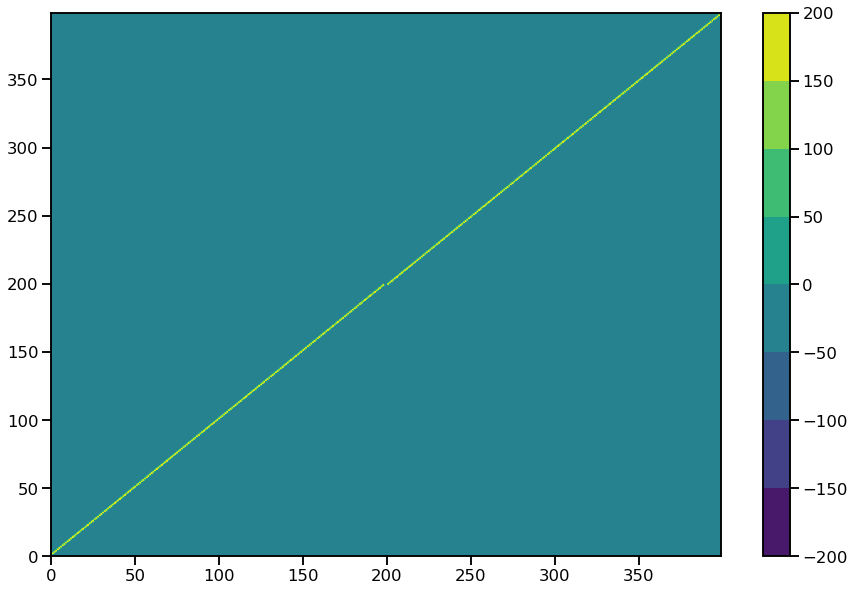

In [61]:
solver=DESolver()
solver.set_info(0)

pde_problem_setup=pde_problem_setup_base.copy()

rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('Advection Reaction 1D',pde_problem_setup)#('Navier-Stokes2D')

solver.setup(keep_history=True)
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)

#solver.set_method('RK4')
solver.set_method('ARK2e')
#solver.set_method('ARK-IMEX-MR4')
#solver.set_method('ARK-IMEX-Mix-1-1')


if(rhs_i is not None):
    solver.set_rhs({'imex_explicit':rhs_e,'imex_implicit':rhs_i})
else:
    solver.set_rhs(rhs_e)
    
problem_setup['DT']=0.05    
problem_setup['T_DURATION']['end']=TEND


print("CFL = {:}".format(pde_problem_setup['Flux_c']*problem_setup['DT']/problem_setup['context']['dx']))
mass_ini=problem.TotalMass(problem.unvectorize(u_ini,problem_setup['context']))
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])

jac_diff,jac,jac_fd=solver.test_Jacobians()
 
fig = plt.figure(figsize=(15, 10))
cs = plt.contourf(jac_diff)#, levels=[10, 30, 50],
##colors=['#808080', '#A0A0A0', '#C0C0C0'], extend='both')
##cs.cmap.set_over('red')
##cs.cmap.set_under('blue')
##cs.changed()
plt.colorbar()
plt.show()


fig = plt.figure(figsize=(15, 10))
cs = plt.contourf(jac_fd)#, levels=[10, 30, 50],
#colors=['#808080', '#A0A0A0', '#C0C0C0'], extend='both')
#cs.cmap.set_over('red')
#cs.cmap.set_under('blue')
#cs.changed()
plt.colorbar()
plt.show()

fig = plt.figure(figsize=(15, 10))
cs = plt.contourf(jac)#, levels=[10, 30, 50],
#colors=['#808080', '#A0A0A0', '#C0C0C0'], extend='both')
#cs.cmap.set_over('red')
#cs.cmap.set_under('blue')
#cs.changed()
plt.colorbar()
plt.show()

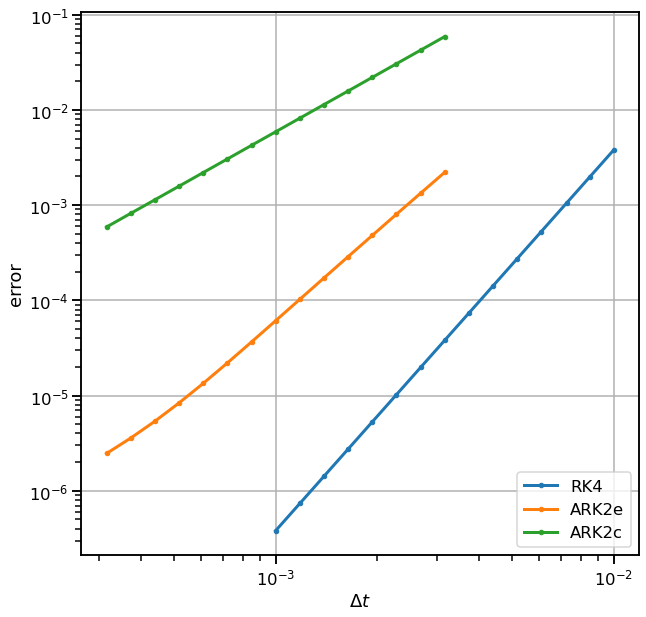

In [4]:
fig = plt.figure(figsize=(10, 10))
for MethodName in Methods_To_Test:
    plt.loglog(AllResults[MethodName]['dt_tab'],AllResults[MethodName]['err_tab_tf'],'.-',lw=3,label=AllResults[MethodName]['method'])

plt.ylabel('error')
plt.xlabel(r'$\Delta t$')
plt.legend(loc='lower right')
plt.grid('both')
#plt.savefig('convergence_lorenz_uh_rk4.png')
#plt.title('Error vs time step obtained with {:}'.format(solver.get_method_name()))
plt.show()